<a href="https://colab.research.google.com/github/addinsalim/Machine-Learning-Course-2026/blob/main/assignments/week-08/2411070071_Sholahuddin%20Yusuf%20Al%20Ayubi/UTS_Medical_Diagnosis_(Classification)_Prediksi_penyakit_kronis_(Diabetes_Jantung)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
import wandb

# Inisialisasi W&B
run = wandb.init(project="breast-cancer-classification", name="logistic-regression-baseline")

# Load dataset langsung dari Scikit-Learn (Dijamin 100% selalu bisa diakses)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0: Malignant (Ganas), 1: Benign (Jinak)

# Log raw data ke W&B Table
wandb.log({"raw_data": wandb.Table(dataframe=df.head(100))})
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


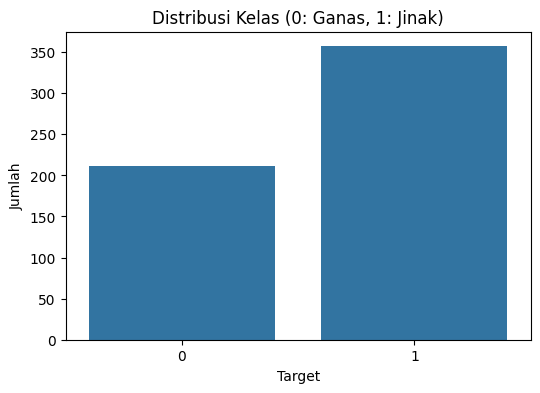

Distribusi Target (Persentase):
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64
⚠️ Data cenderung tidak seimbang (imbalanced)

Jumlah fitur: 30

Jumlah data training: 455
Jumlah data testing : 114


In [36]:
# =========================
# CEK DISTRIBUSI TARGET
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(x=df['target'])
plt.title("Distribusi Kelas (0: Ganas, 1: Jinak)")
plt.xlabel("Target")
plt.ylabel("Jumlah")
plt.show()

# Tampilkan proporsi dalam persen (PENTING untuk analisis)
class_dist = df['target'].value_counts(normalize=True)
print("Distribusi Target (Persentase):")
print(class_dist)

# Insight sederhana (biar ada analisis)
if abs(class_dist[0] - class_dist[1]) > 0.2:
    print("⚠️ Data cenderung tidak seimbang (imbalanced)")
else:
    print("✅ Data relatif seimbang")

# =========================
# PISAHKAN FITUR & TARGET
# =========================
X = df.drop('target', axis=1)
y = df['target']

print("\nJumlah fitur:", X.shape[1])

# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # menjaga proporsi kelas tetap sama
)

print("\nJumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

# =========================
# W&B CONFIG (LEBIH AMAN)
# =========================
try:
    if wandb.run is not None:
        wandb.config.update({
            "test_size": 0.2,
            "random_state": 42,
            "n_features": X.shape[1]
        })
except Exception as e:
    print("W&B belum aktif:", e)

In [37]:
# =========================
# TRAINING MODEL
# =========================

print("🚀 Training Models...\n")

# Logistic Regression
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression selesai")

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("✅ Decision Tree selesai")

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest selesai")

# =========================
# PREDIKSI
# =========================

y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("\n🎯 Prediksi selesai untuk semua model")

# =========================
# LOG MODEL KE W&B (OPSIONAL BONUS)
# =========================
try:
    if wandb.run is not None:
        wandb.watch(lr_model)
        wandb.watch(dt_model)
        wandb.watch(rf_model)
except:
    print("W&B tidak aktif")

🚀 Training Models...

✅ Logistic Regression selesai
✅ Decision Tree selesai
✅ Random Forest selesai

🎯 Prediksi selesai untuk semua model
W&B tidak aktif


In [38]:
def evaluate_model(model, name):
    # =========================
    # PREDIKSI
    # =========================
    y_pred = model.predict(X_test)

    # =========================
    # METRIK
    # =========================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # =========================
    # PRINT HASIL
    # =========================
    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

    # =========================
    # CLASSIFICATION REPORT
    # =========================
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # =========================
    # LOG KE W&B
    # =========================
    try:
        if wandb.run is not None:
            wandb.log({
                f"{name}_Accuracy": acc,
                f"{name}_Precision": prec,
                f"{name}_Recall": rec,
                f"{name}_F1": f1
            })
    except:
        print("W&B belum aktif")

    # =========================
    # RETURN HASIL (PENTING UNTUK PERBANDINGAN)
    # =========================
    return {
        "name": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

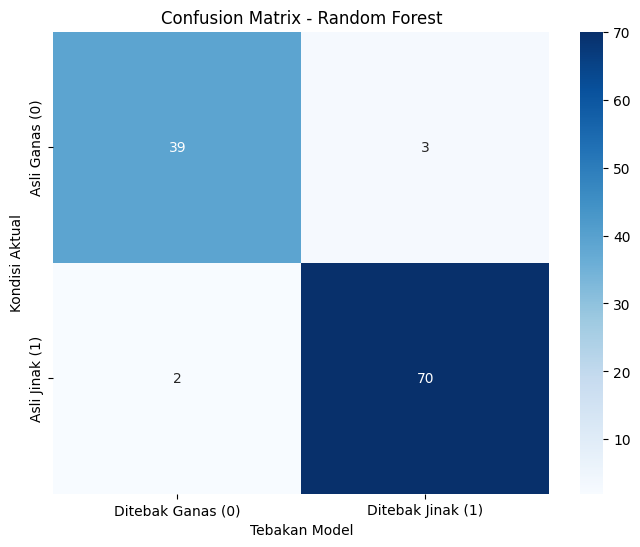


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [39]:
# Contoh untuk Random Forest (model terbaik biasanya)

y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ditebak Ganas (0)', 'Ditebak Jinak (1)'],
            yticklabels=['Asli Ganas (0)', 'Asli Jinak (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Kondisi Aktual')
plt.xlabel('Tebakan Model')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))